In [27]:
# NumPyライブラリの読み込み
import numpy as np

In [37]:
# MAPの定義と関連する関数、および表示

MAP_WIDTH = 5
MAP_HEIGHT = 5
MAP_COLOR = [
    'white',# 0: Road 通過可能
    'black',# 1: Wall 通ることができない内壁（基礎演習1）
    'gold' ,# 2: Goal 着いたら終了
]

# MAPの定義
MAP = np.array([
    [2, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0]
])

# 座標 pos = [x, y] に移動可能か判定する関数
def is_movable(pos):
    x = pos[0]
    y = pos[1]
    if x < 0 or x > MAP_WIDTH - 1:
        return False
    if y < 0 or y > MAP_HEIGHT - 1:
        return False
    return True

# 座標 pos = [x, y] がゴールか判定する関数
def is_goal(pos):
    x = pos[0]
    y = pos[1]
    if MAP[y][x] == 2:
        return True

    if MAP[y][x] == 1:
        return False

    return False

In [38]:
# エージェントに関する定義と関数

A_START = [4, 4] #エージェントのスタート位置

#エージェントの位置から状態番号に変換
def pos_to_state(pos):
    return MAP_HEIGHT*pos[0]+pos[1]

# エージェントの状態番号から位置に変換
def state_to_pos(s):
    return [s//MAP_HEIGHT,s%MAP_HEIGHT]

In [39]:
# エージェントの行動に関する関数

# 行動選択関数（今回はランダム）
def get_action(s):
    a_next = np.random.choice(range(4))
    return a_next

# 次の状態の決定
def get_s_next(s, a):
    [x, y] = state_to_pos(s)
    if a == 0: #up
        y = y - 1
    elif a == 1: #down
        y = y + 1
    elif a == 2: #left
        x = x - 1
    elif a == 3: #right
        x = x + 1
    if is_movable([x, y]): #移動可能な場合のみ移動
        return pos_to_state([x, y])
    else:
        return s

In [42]:
# スタートからゴールまでの経路計算（無駄な動きを除外）
def episode():
    # 初期位置の設定
    s = pos_to_state(A_START)
    # 最初の履歴を追加（行動はまだ決まっていないのでnan）
    s_a_history = [[s, np.nan]]

    # 最大300ステップの探索
    for step in range(300):
        # 現在の状態から行動を取得
        a = get_action(s)

        # 次の状態を計算
        s_next = get_s_next(s, a)

        # --- ここがポイント：移動に成功（状態が変化）した場合のみ記録 ---
        if s_next != s:
            # 直前の履歴に行動を書き込む
            s_a_history[-1][1] = a
            # 新しい状態を履歴に追加
            s_a_history.append([s_next, np.nan])

            # ゴール判定
            if is_goal(state_to_pos(s_next)):
                break

            # 状態を更新して次のステップへ
            s = s_next
        else:
            # 壁にぶつかった場合は何もしない（履歴に追加せず、同じ場所からやり直し）
            continue

    return [s_a_history]

number of steps:120


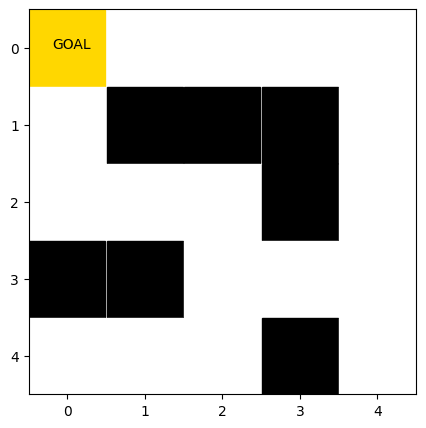

In [43]:
# 最終結果のアニメーションの表示

# 必要ライブラリの読み込み
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# マップの表示設定
fig = plt.figure(figsize=(MAP_WIDTH,MAP_HEIGHT))
ax = plt.gca()
ax.set_xlim(-0.5,MAP_WIDTH-0.5)
ax.set_ylim(MAP_HEIGHT-0.5,-0.5)
for i in range(MAP_HEIGHT):
    for j in range(MAP_WIDTH):
        ax.plot(j,i, marker='s', color = MAP_COLOR[MAP[i][j]], markersize=55)
        if(MAP[i][j]==2):
            ax.text(j-0.2,i,'GOAL')

# 経路の計算
[history] = episode()
print("number of steps:" + str(len(history)-1))

# 各時点での画像の作成
ims = []
for i in range(len(history)):
    s = history[i][0]
    [x, y] = state_to_pos(s)
    p = ax.plot(x, y, marker='o', color='green', markersize=40)
    ims.append(p)

# アニメーション作成と表示
anim = animation.ArtistAnimation(fig, ims, interval=300, repeat=False)
# anim.save("anim.mp4") #アニメーションファイルの保存をする場合
HTML(anim.to_jshtml())